# 🏢 End-to-End HR Attrition Analytics — Capstone
**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle)  


## 0. Setup & Kaggle Dataset Download

In [1]:
# ── Install & import ──────────────────────────────────────────────────────────
import subprocess, sys, os

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

install('kaggle')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings, os

warnings.filterwarnings('ignore')

# ── Plotting style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
})
PALETTE = ['#E74C3C', '#2ECC71']   # red = churned, green = retained

print('✅ Libraries loaded.')

✅ Libraries loaded.


In [2]:
DATA_DIR  = 'data'
DATA_FILE = f'{DATA_DIR}/WA_Fn-UseC_-HR-Employee-Attrition.csv'

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(DATA_FILE):
    print('⬇️  Downloading dataset from Kaggle...')
    os.system(
        f'kaggle datasets download -d pavansubhasht/ibm-hr-analytics-attrition-dataset '
        f'--unzip -p {DATA_DIR}'
    )
    print('✅ Download complete.')
else:
    print('✅ Dataset already present — skipping download.')

df_raw = pd.read_csv(DATA_FILE)
print(f'Shape: {df_raw.shape}  |  Columns: {df_raw.shape[1]}')
df_raw.head(3)

⬇️  Downloading dataset from Kaggle...
✅ Download complete.
Shape: (1470, 35)  |  Columns: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


## 1. Data Preparation

In [3]:
# ── Copy raw data; convert Attrition to binary ────────────────────────────────
df = df_raw.copy()
df['AttritionBin'] = (df['Attrition'] == 'Yes').astype(int)

# ── Basic checks ──────────────────────────────────────────────────────────────
print('Missing values:', df.isnull().sum().sum())
print('Attrition distribution:')
print(df['Attrition'].value_counts())
print(f'\nOverall attrition rate: {df["AttritionBin"].mean():.1%}')

Missing values: 0
Attrition distribution:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Overall attrition rate: 16.1%


In [4]:
# ── Tenure groups ─────────────────────────────────────────────────────────────
bins   = [-1, 2, 5, 10, 999]
labels = ['0–2 yrs', '3–5 yrs', '6–10 yrs', '11+ yrs']
df['TenureGroup'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

# ── Income quartile groups ────────────────────────────────────────────────────
df['IncomeQuartile'] = pd.qcut(
    df['MonthlyIncome'], q=4,
    labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4 (High)']
)

print('TenureGroup counts:')
print(df['TenureGroup'].value_counts().sort_index())
print('\nIncomeQuartile counts:')
print(df['IncomeQuartile'].value_counts().sort_index())

TenureGroup counts:
TenureGroup
0–2 yrs     342
3–5 yrs     434
6–10 yrs    448
11+ yrs     246
Name: count, dtype: int64

IncomeQuartile counts:
IncomeQuartile
Q1 (Low)     369
Q2           366
Q3           367
Q4 (High)    368
Name: count, dtype: int64


## 2. KPI Summary Table — Churned vs. Retained

In [5]:
# ── Compute KPIs per attrition group ─────────────────────────────────────────
kpi_cols = ['MonthlyIncome', 'YearsAtCompany', 'JobSatisfaction',
            'WorkLifeBalance', 'Age']

kpi = (
    df.groupby('Attrition')
    .agg(
        TotalEmployees   = ('EmployeeNumber', 'count'),
        AvgMonthlyIncome = ('MonthlyIncome',  'mean'),
        AvgYearsAtCompany= ('YearsAtCompany', 'mean'),
        AvgJobSatisfaction=('JobSatisfaction','mean'),
        AvgWorkLifeBalance=('WorkLifeBalance','mean'),
        AvgAge           = ('Age',            'mean'),
    )
    .T
)
kpi.columns.name = None

# Add attrition rate row
total = kpi.loc['TotalEmployees']
kpi.loc['AttritionRate (%)'] = [
    f"{100*int(total['Yes'])/(int(total['Yes'])+int(total['No'])):.1f}%",
    '—'
]

# Round numerics
kpi_display = kpi.copy()
for col in kpi_display.columns:
    kpi_display[col] = kpi_display[col].apply(
        lambda x: f'{float(x):,.2f}' if isinstance(x, (int, float)) else x
    )

print('─' * 55)
print('KPI SUMMARY TABLE: Churned vs. Retained Employees')
print('─' * 55)
print(kpi_display.rename(columns={'Yes': '🔴 Churned', 'No': '🟢 Retained'}).to_string())
print('─' * 55)

───────────────────────────────────────────────────────
KPI SUMMARY TABLE: Churned vs. Retained Employees
───────────────────────────────────────────────────────
                   🟢 Retained 🔴 Churned
TotalEmployees       1,233.00    237.00
AvgMonthlyIncome     6,832.74  4,787.09
AvgYearsAtCompany        7.37      5.13
AvgJobSatisfaction       2.78      2.47
AvgWorkLifeBalance       2.78      2.66
AvgAge                  37.56     33.61
AttritionRate (%)       16.1%         —
───────────────────────────────────────────────────────


In [6]:
# ── Styled KPI table (rendered as DataFrame) ──────────────────────────────────
kpi_styled = (
    df.groupby('Attrition')
    .agg(
        TotalEmployees    = ('EmployeeNumber', 'count'),
        AttritionRate_pct = ('AttritionBin',   'mean'),
        AvgMonthlyIncome  = ('MonthlyIncome',  'mean'),
        AvgYearsAtCompany = ('YearsAtCompany', 'mean'),
        AvgJobSatisfaction= ('JobSatisfaction','mean'),
        AvgWorkLifeBalance= ('WorkLifeBalance','mean'),
    )
    .rename(index={'Yes': '🔴 Churned', 'No': '🟢 Retained'})
    .T
)

kpi_styled.style \
    .set_caption('📊 KPI Summary: Churned vs. Retained Employees') \
    .format({'🔴 Churned': '{:.2f}', '🟢 Retained': '{:.2f}'}) \
    .background_gradient(axis=1, cmap='RdYlGn_r', subset=pd.IndexSlice[['AvgMonthlyIncome'], :])

Attrition,🟢 Retained,🔴 Churned
TotalEmployees,1233.00,237.00
AttritionRate_pct,0.00,1.00
AvgMonthlyIncome,6832.74,4787.09
AvgYearsAtCompany,7.37,5.13
AvgJobSatisfaction,2.78,2.47
AvgWorkLifeBalance,2.78,2.66


## 3. Attrition Rate by Key Dimensions

In [7]:
# ── Helper ────────────────────────────────────────────────────────────────────
def attrition_rate(df, col):
    return (
        df.groupby(col)['AttritionBin']
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'AttritionRate', 'count': 'Headcount'})
        .sort_values('AttritionRate', ascending=False)
        .assign(AttritionRate=lambda x: x['AttritionRate'] * 100)
    )

# ── Department ────────────────────────────────────────────────────────────────
dept_attr = attrition_rate(df, 'Department')
print('Department:')
print(dept_attr)

# ── JobRole ───────────────────────────────────────────────────────────────────
role_attr = attrition_rate(df, 'JobRole')
print('\nJobRole:')
print(role_attr)

# ── OverTime ──────────────────────────────────────────────────────────────────
ot_attr = attrition_rate(df, 'OverTime')
print('\nOverTime:')
print(ot_attr)

# ── MaritalStatus ─────────────────────────────────────────────────────────────
ms_attr = attrition_rate(df, 'MaritalStatus')
print('\nMaritalStatus:')
print(ms_attr)

# ── Gender ────────────────────────────────────────────────────────────────────
g_attr = attrition_rate(df, 'Gender')
print('\nGender:')
print(g_attr)

Department:
                        AttritionRate  Headcount
Department                                      
Sales                       20.627803        446
Human Resources             19.047619         63
Research & Development      13.839750        961

JobRole:
                           AttritionRate  Headcount
JobRole                                            
Sales Representative           39.759036         83
Laboratory Technician          23.938224        259
Human Resources                23.076923         52
Sales Executive                17.484663        326
Research Scientist             16.095890        292
Manufacturing Director          6.896552        145
Healthcare Representative       6.870229        131
Manager                         4.901961        102
Research Director               2.500000         80

OverTime:
          AttritionRate  Headcount
OverTime                          
Yes           30.528846        416
No            10.436433       1054

MaritalSt

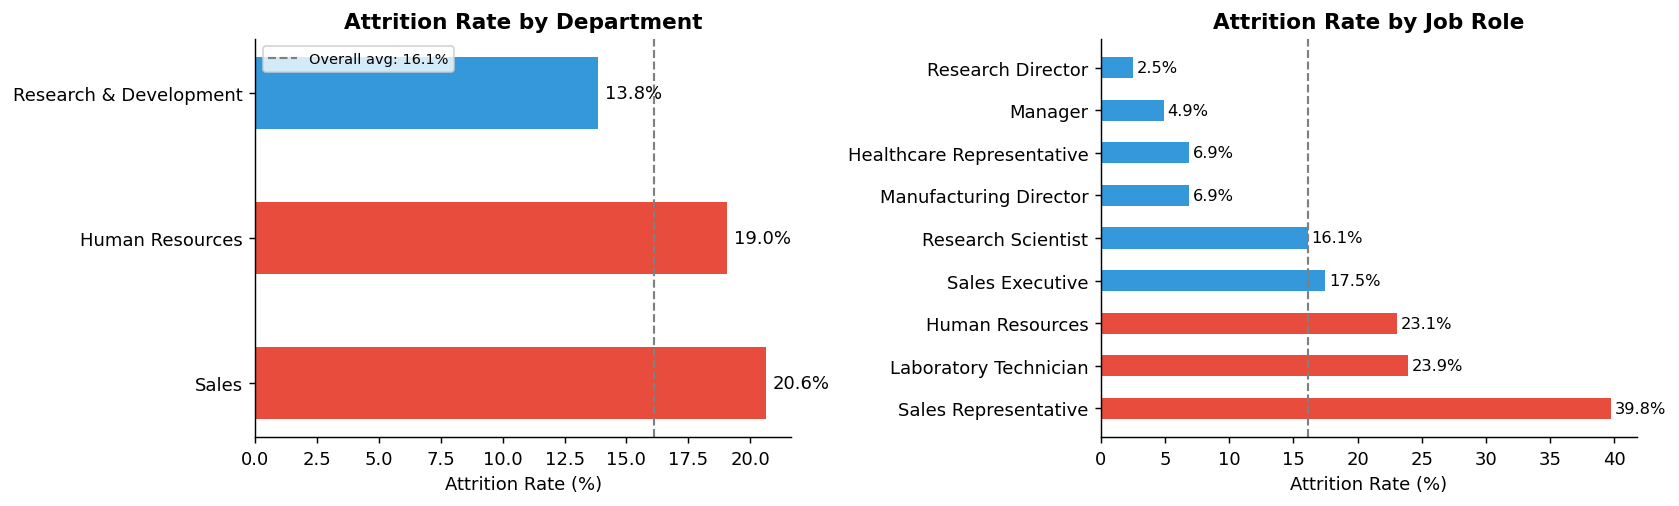

Figure saved: attrition_by_dept_role.png


In [8]:
# ── Visualization 1: Attrition rate by Department ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Department
ax = axes[0]
colors = ['#E74C3C' if v > 16 else '#3498DB' for v in dept_attr['AttritionRate']]
bars = ax.barh(dept_attr.index, dept_attr['AttritionRate'], color=colors, height=0.5)
ax.axvline(df['AttritionBin'].mean()*100, color='gray', linestyle='--', lw=1.2, label=f'Overall avg: {df["AttritionBin"].mean()*100:.1f}%')
for bar, v in zip(bars, dept_attr['AttritionRate']):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Department', fontweight='bold')
ax.legend(fontsize=8)

# JobRole
ax = axes[1]
colors = ['#E74C3C' if v > 20 else '#3498DB' for v in role_attr['AttritionRate']]
bars = ax.barh(role_attr.index, role_attr['AttritionRate'], color=colors, height=0.5)
ax.axvline(df['AttritionBin'].mean()*100, color='gray', linestyle='--', lw=1.2)
for bar, v in zip(bars, role_attr['AttritionRate']):
    ax.text(v+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Job Role', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_by_dept_role.png', bbox_inches='tight')
plt.show()
print('Figure saved: attrition_by_dept_role.png')

## 4. Tenure & Income Group Analysis

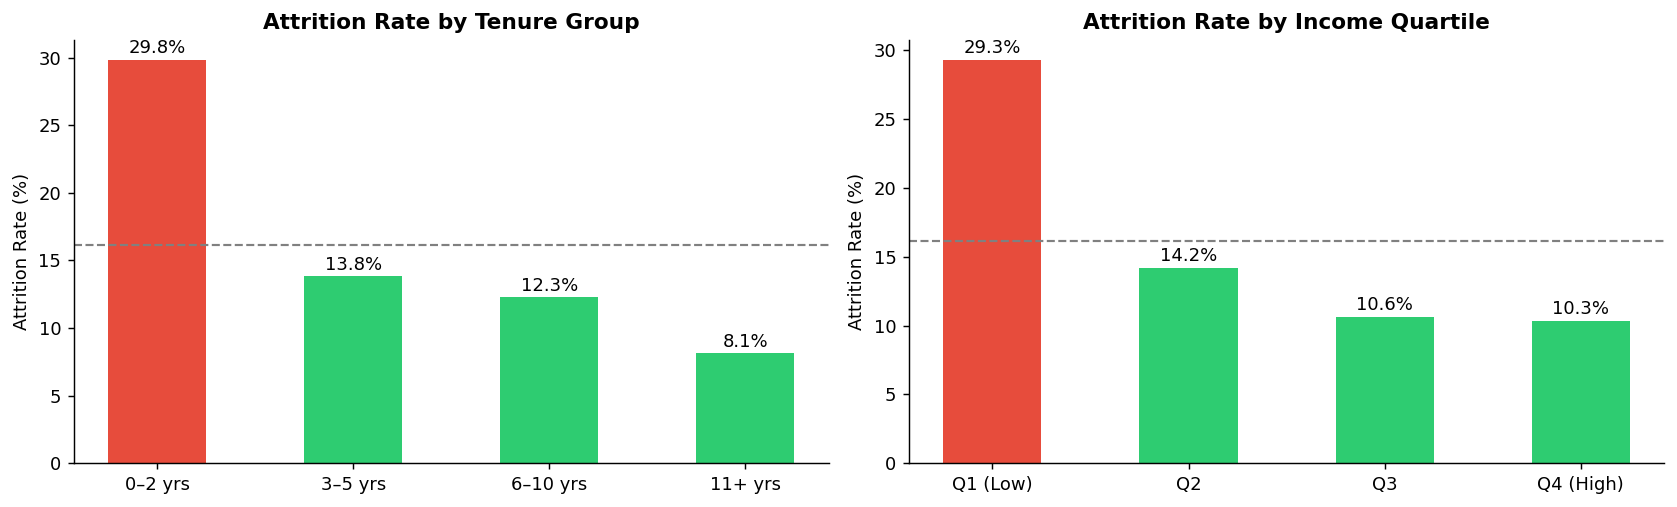

Tenure:
             AttritionRate  Headcount
TenureGroup                          
0–2 yrs          29.824561        342
3–5 yrs          13.824885        434
6–10 yrs         12.276786        448
11+ yrs           8.130081        246

Income Quartile:
                AttritionRate  Headcount
IncomeQuartile                          
Q1 (Low)            29.268293        369
Q2                  14.207650        366
Q3                  10.626703        367
Q4 (High)           10.326087        368


In [9]:
# ── Attrition by Tenure Group ─────────────────────────────────────────────────
tenure_attr = (
    df.groupby('TenureGroup', observed=True)['AttritionBin']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'AttritionRate', 'count': 'Headcount'})
    .assign(AttritionRate=lambda x: x['AttritionRate'] * 100)
)

# ── Attrition by Income Quartile ──────────────────────────────────────────────
income_attr = (
    df.groupby('IncomeQuartile', observed=True)['AttritionBin']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'AttritionRate', 'count': 'Headcount'})
    .assign(AttritionRate=lambda x: x['AttritionRate'] * 100)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Tenure bar
ax = axes[0]
clrs = ['#E74C3C' if v > 20 else '#F39C12' if v > 15 else '#2ECC71'
        for v in tenure_attr['AttritionRate']]
bars = ax.bar(tenure_attr.index, tenure_attr['AttritionRate'], color=clrs, width=0.5)
ax.axhline(df['AttritionBin'].mean()*100, color='gray', linestyle='--', lw=1.2)
for bar, v in zip(bars, tenure_attr['AttritionRate']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Tenure Group', fontweight='bold')

# Income quartile bar
ax = axes[1]
clrs = ['#E74C3C' if v > 20 else '#F39C12' if v > 15 else '#2ECC71'
        for v in income_attr['AttritionRate']]
bars = ax.bar(income_attr.index, income_attr['AttritionRate'], color=clrs, width=0.5)
ax.axhline(df['AttritionBin'].mean()*100, color='gray', linestyle='--', lw=1.2)
for bar, v in zip(bars, income_attr['AttritionRate']):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Income Quartile', fontweight='bold')

plt.tight_layout()
plt.savefig('attrition_tenure_income.png', bbox_inches='tight')
plt.show()

print('Tenure:')
print(tenure_attr)
print('\nIncome Quartile:')
print(income_attr)

## 5. Dual Pivot Analysis

In [10]:
# ── Pivot 1: Department × JobSatisfaction → Attrition Rate % ──────────────────
pivot_js = df.pivot_table(
    index='Department',
    columns='JobSatisfaction',
    values='AttritionBin',
    aggfunc='mean'
) * 100

pivot_js.columns = [f'JobSat={c}' for c in pivot_js.columns]

print('Pivot 1: Department × JobSatisfaction → Attrition Rate (%)')
print(pivot_js.round(1))

# ── Pivot 2: Department × WorkLifeBalance → Attrition Rate % ─────────────────
pivot_wlb = df.pivot_table(
    index='Department',
    columns='WorkLifeBalance',
    values='AttritionBin',
    aggfunc='mean'
) * 100

pivot_wlb.columns = [f'WLB={c}' for c in pivot_wlb.columns]

print('\nPivot 2: Department × WorkLifeBalance → Attrition Rate (%)')
print(pivot_wlb.round(1))

Pivot 1: Department × JobSatisfaction → Attrition Rate (%)
                        JobSat=1  JobSat=2  JobSat=3  JobSat=4
Department                                                    
Human Resources             45.5      10.0      20.0      11.8
Research & Development      19.8      13.8      14.3       9.5
Sales                       26.7      23.3      21.3      15.0

Pivot 2: Department × WorkLifeBalance → Attrition Rate (%)
                        WLB=1  WLB=2  WLB=3  WLB=4
Department                                        
Human Resources           0.0   28.6   21.4   10.0
Research & Development   31.7   13.6   11.8   15.4
Sales                    37.5   23.5   18.1   23.1


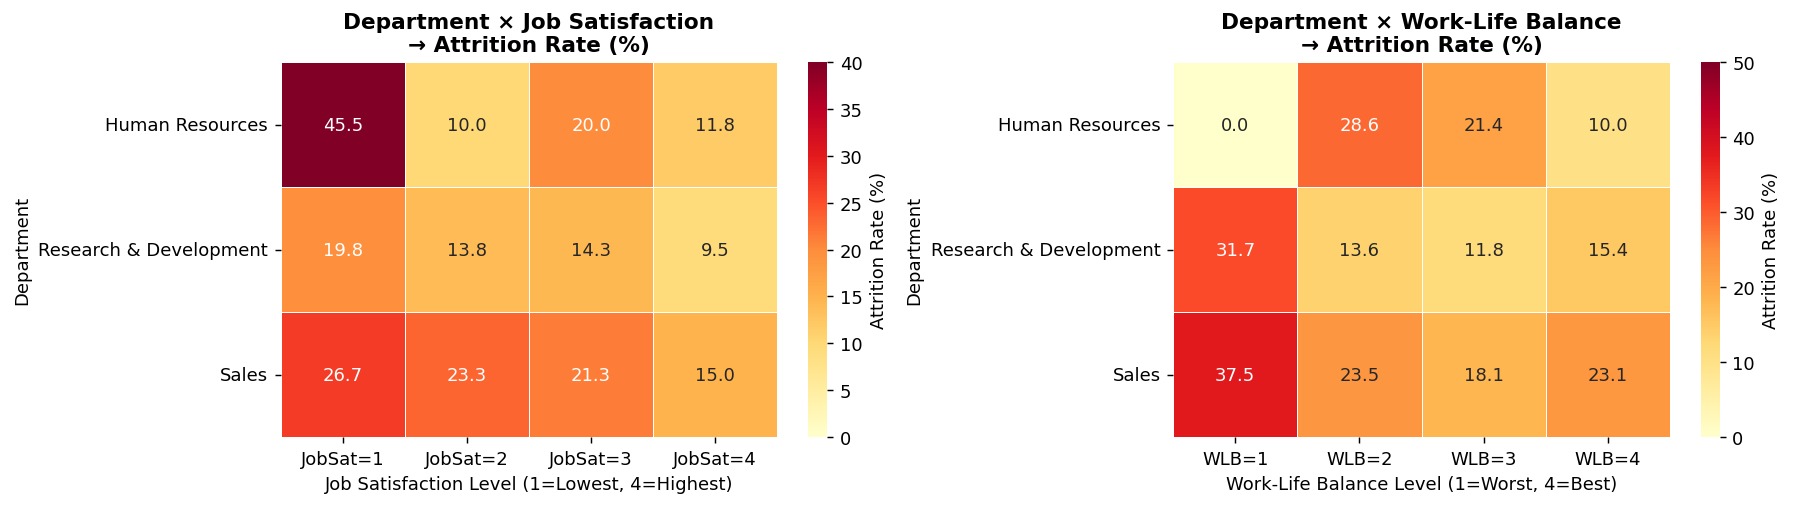

Figure saved: pivot_heatmaps.png


In [11]:
# ── Heatmap visualizations ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pivot 1 Heatmap
sns.heatmap(
    pivot_js, ax=axes[0],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'},
    vmin=0, vmax=40
)
axes[0].set_title('Department × Job Satisfaction\n→ Attrition Rate (%)', fontweight='bold')
axes[0].set_xlabel('Job Satisfaction Level (1=Lowest, 4=Highest)')

# Pivot 2 Heatmap
sns.heatmap(
    pivot_wlb, ax=axes[1],
    annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'},
    vmin=0, vmax=50
)
axes[1].set_title('Department × Work-Life Balance\n→ Attrition Rate (%)', fontweight='bold')
axes[1].set_xlabel('Work-Life Balance Level (1=Worst, 4=Best)')

plt.tight_layout()
plt.savefig('pivot_heatmaps.png', bbox_inches='tight')
plt.show()
print('Figure saved: pivot_heatmaps.png')

## 6. Correlation Ranking — Top 10 Drivers of Attrition

In [12]:
# ── Correlate all numeric columns with AttritionBin ───────────────────────────
numeric_df = df.select_dtypes(include='number').drop(columns=['AttritionBin'], errors='ignore')

# Also encode OverTime for correlation (Yes=1, No=0)
numeric_df['OverTime_Enc'] = (df['OverTime'] == 'Yes').astype(int)

corr_series = (
    numeric_df
    .corrwith(df['AttritionBin'])
    .dropna()
    .sort_values(key=abs, ascending=False)
    .head(10)
)

print('Top 10 correlations with Attrition (by |r|):')
for name, val in corr_series.items():
    bar = '█' * int(abs(val) * 40)
    sign = '+' if val > 0 else '-'
    print(f'  {name:<30} {sign}{abs(val):.3f}  {bar}')

Top 10 correlations with Attrition (by |r|):
  OverTime_Enc                   +0.246  █████████
  TotalWorkingYears              -0.171  ██████
  JobLevel                       -0.169  ██████
  YearsInCurrentRole             -0.161  ██████
  MonthlyIncome                  -0.160  ██████
  Age                            -0.159  ██████
  YearsWithCurrManager           -0.156  ██████
  StockOptionLevel               -0.137  █████
  YearsAtCompany                 -0.134  █████
  JobInvolvement                 -0.130  █████


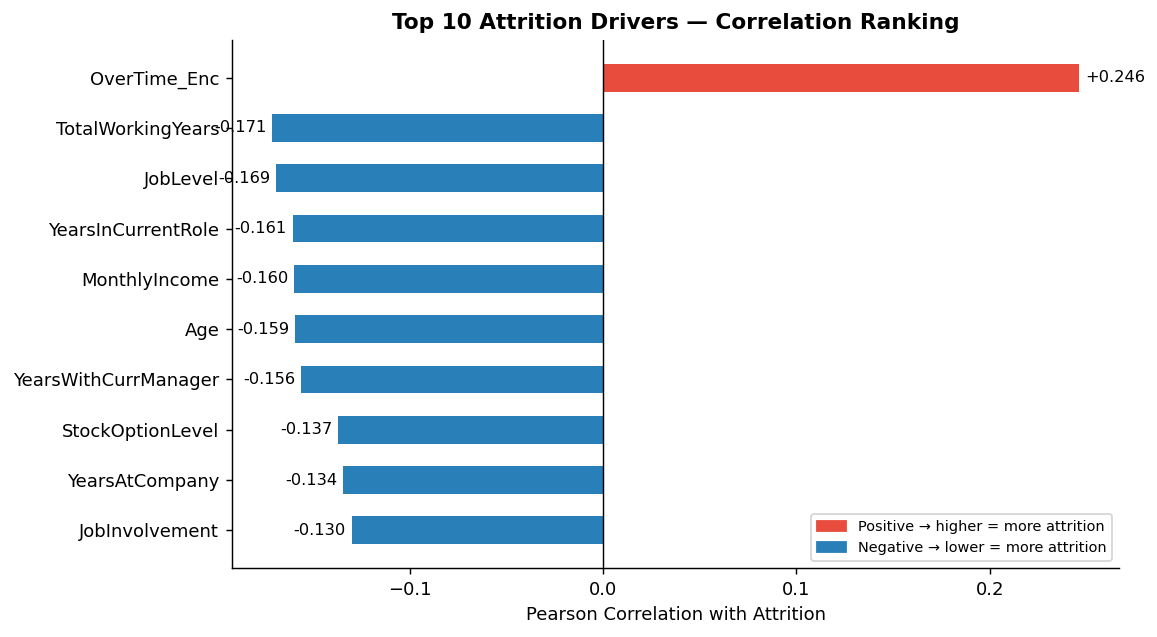

Figure saved: top10_correlations.png


In [13]:
# ── Horizontal bar chart: Top 10 correlations ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#E74C3C' if v > 0 else '#2980B9' for v in corr_series.values]
bars = ax.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1], height=0.55)

for bar, v in zip(bars, corr_series.values[::-1]):
    xpos = v + 0.003 if v >= 0 else v - 0.003
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f'{v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right', fontsize=9)

ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Pearson Correlation with Attrition')
ax.set_title('Top 10 Attrition Drivers — Correlation Ranking', fontweight='bold')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#E74C3C', label='Positive → higher = more attrition'),
    Patch(color='#2980B9', label='Negative → lower = more attrition'),
], fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('top10_correlations.png', bbox_inches='tight')
plt.show()
print('Figure saved: top10_correlations.png')

## 7. High-Risk Employee Profiles

In [14]:
# ── Profile 1: OverTime=Yes + Tenure 0–2 yrs ─────────────────────────────────
p1 = df[(df['OverTime'] == 'Yes') & (df['TenureGroup'] == '0–2 yrs')]
p1_rate = p1['AttritionBin'].mean()
print(f'Profile 1 — OverTime=Yes & Tenure 0–2 yrs')
print(f'  Headcount: {len(p1)}  |  Attrition Rate: {p1_rate:.1%}')

# ── Profile 2: JobSatisfaction=1 + OverTime=Yes ───────────────────────────────
p2 = df[(df['JobSatisfaction'] == 1) & (df['OverTime'] == 'Yes')]
p2_rate = p2['AttritionBin'].mean()
print(f'\nProfile 2 — JobSatisfaction=1 & OverTime=Yes')
print(f'  Headcount: {len(p2)}  |  Attrition Rate: {p2_rate:.1%}')

# ── Profile 3: WorkLifeBalance=1 + IncomeQuartile=Q1 ─────────────────────────
p3 = df[(df['WorkLifeBalance'] == 1) & (df['IncomeQuartile'] == 'Q1 (Low)')]
p3_rate = p3['AttritionBin'].mean()
print(f'\nProfile 3 — WorkLifeBalance=1 & Income Q1 (Lowest)')
print(f'  Headcount: {len(p3)}  |  Attrition Rate: {p3_rate:.1%}')

Profile 1 — OverTime=Yes & Tenure 0–2 yrs
  Headcount: 104  |  Attrition Rate: 51.0%

Profile 2 — JobSatisfaction=1 & OverTime=Yes
  Headcount: 84  |  Attrition Rate: 35.7%

Profile 3 — WorkLifeBalance=1 & Income Q1 (Lowest)
  Headcount: 21  |  Attrition Rate: 52.4%


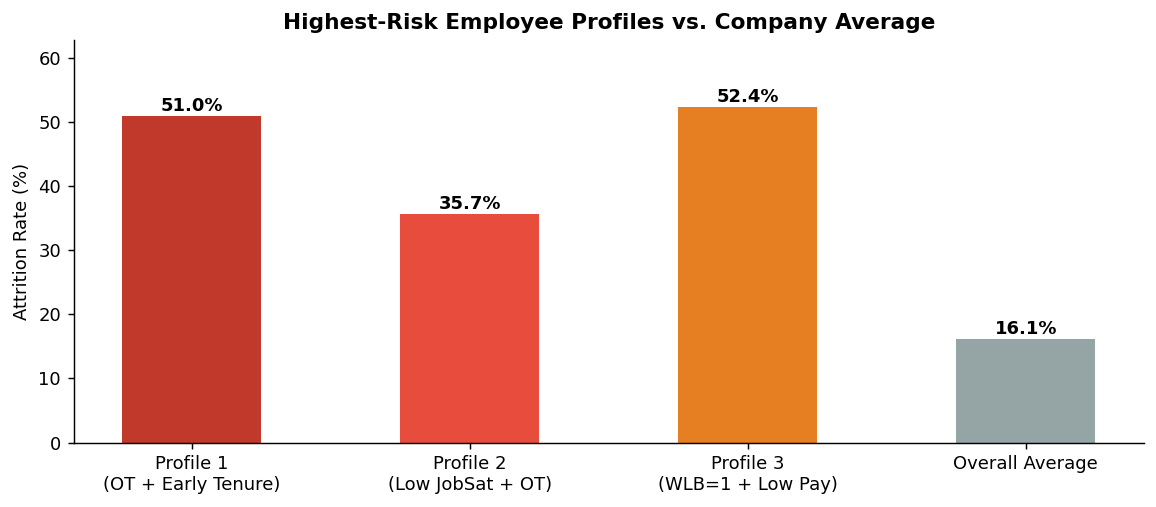

In [15]:
# ── Risk profile visualization ────────────────────────────────────────────────
profiles = {
    'Profile 1\n(OT + Early Tenure)': p1_rate * 100,
    'Profile 2\n(Low JobSat + OT)':   p2_rate * 100,
    'Profile 3\n(WLB=1 + Low Pay)':   p3_rate * 100,
    'Overall Average':                 df['AttritionBin'].mean() * 100,
}

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#C0392B', '#E74C3C', '#E67E22', '#95A5A6']
bars = ax.bar(profiles.keys(), profiles.values(), color=colors, width=0.5)
for bar, v in zip(bars, profiles.values()):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Highest-Risk Employee Profiles vs. Company Average', fontweight='bold')
ax.set_ylim(0, max(profiles.values()) * 1.2)

plt.tight_layout()
plt.savefig('risk_profiles.png', bbox_inches='tight')
plt.show()

## 8. ⭐ Bonus: Cost of Attrition

In [16]:
# ── Assumption: replacement cost = 6 months salary per churned employee ────────
churned = df[df['Attrition'] == 'Yes']
total_churned = len(churned)
avg_monthly_income_churned = churned['MonthlyIncome'].mean()
replacement_cost_per_employee = avg_monthly_income_churned * 6
total_annual_cost = replacement_cost_per_employee * total_churned

print('=' * 55)
print('💸 COST OF ATTRITION ESTIMATION')
print('=' * 55)
print(f'  Total churned employees         : {total_churned:,}')
print(f'  Avg monthly income (churned)    : ${avg_monthly_income_churned:,.0f}')
print(f'  Replacement cost per employee   : ${replacement_cost_per_employee:,.0f}  (6 months salary)')
print(f'  ─────────────────────────────────────────────────────')
print(f'  💰 Estimated total annual cost  : ${total_annual_cost:,.0f}')
print('=' * 55)

💸 COST OF ATTRITION ESTIMATION
  Total churned employees         : 237
  Avg monthly income (churned)    : $4,787
  Replacement cost per employee   : $28,723  (6 months salary)
  ─────────────────────────────────────────────────────
  💰 Estimated total annual cost  : $6,807,246


## 9. ⭐ Bonus: Triple-Risk Segment — OverTime=Yes + JobSatisfaction=1 + Low Income

In [17]:
# ── Define 'low income' as Q1 (bottom 25%) ────────────────────────────────────
q1_threshold = df['MonthlyIncome'].quantile(0.25)

triple_risk = df[
    (df['OverTime'] == 'Yes') &
    (df['JobSatisfaction'] == 1) &
    (df['MonthlyIncome'] <= q1_threshold)
]

print(f'Q1 income threshold               : ${q1_threshold:,.0f}')
print(f'Triple-risk segment headcount     : {len(triple_risk)}')
print(f'Triple-risk attrition rate        : {triple_risk["AttritionBin"].mean():.1%}')
print(f'Company overall attrition rate    : {df["AttritionBin"].mean():.1%}')
print()
if len(triple_risk) > 0:
    ratio = triple_risk['AttritionBin'].mean() / df['AttritionBin'].mean()
    print(f'🚨 This segment leaves at {ratio:.1f}x the company average!')
else:
    print('No employees match all three criteria in this dataset.')

Q1 income threshold               : $2,911
Triple-risk segment headcount     : 23
Triple-risk attrition rate        : 65.2%
Company overall attrition rate    : 16.1%

🚨 This segment leaves at 4.0x the company average!


## 10. Executive Summary Dashboard

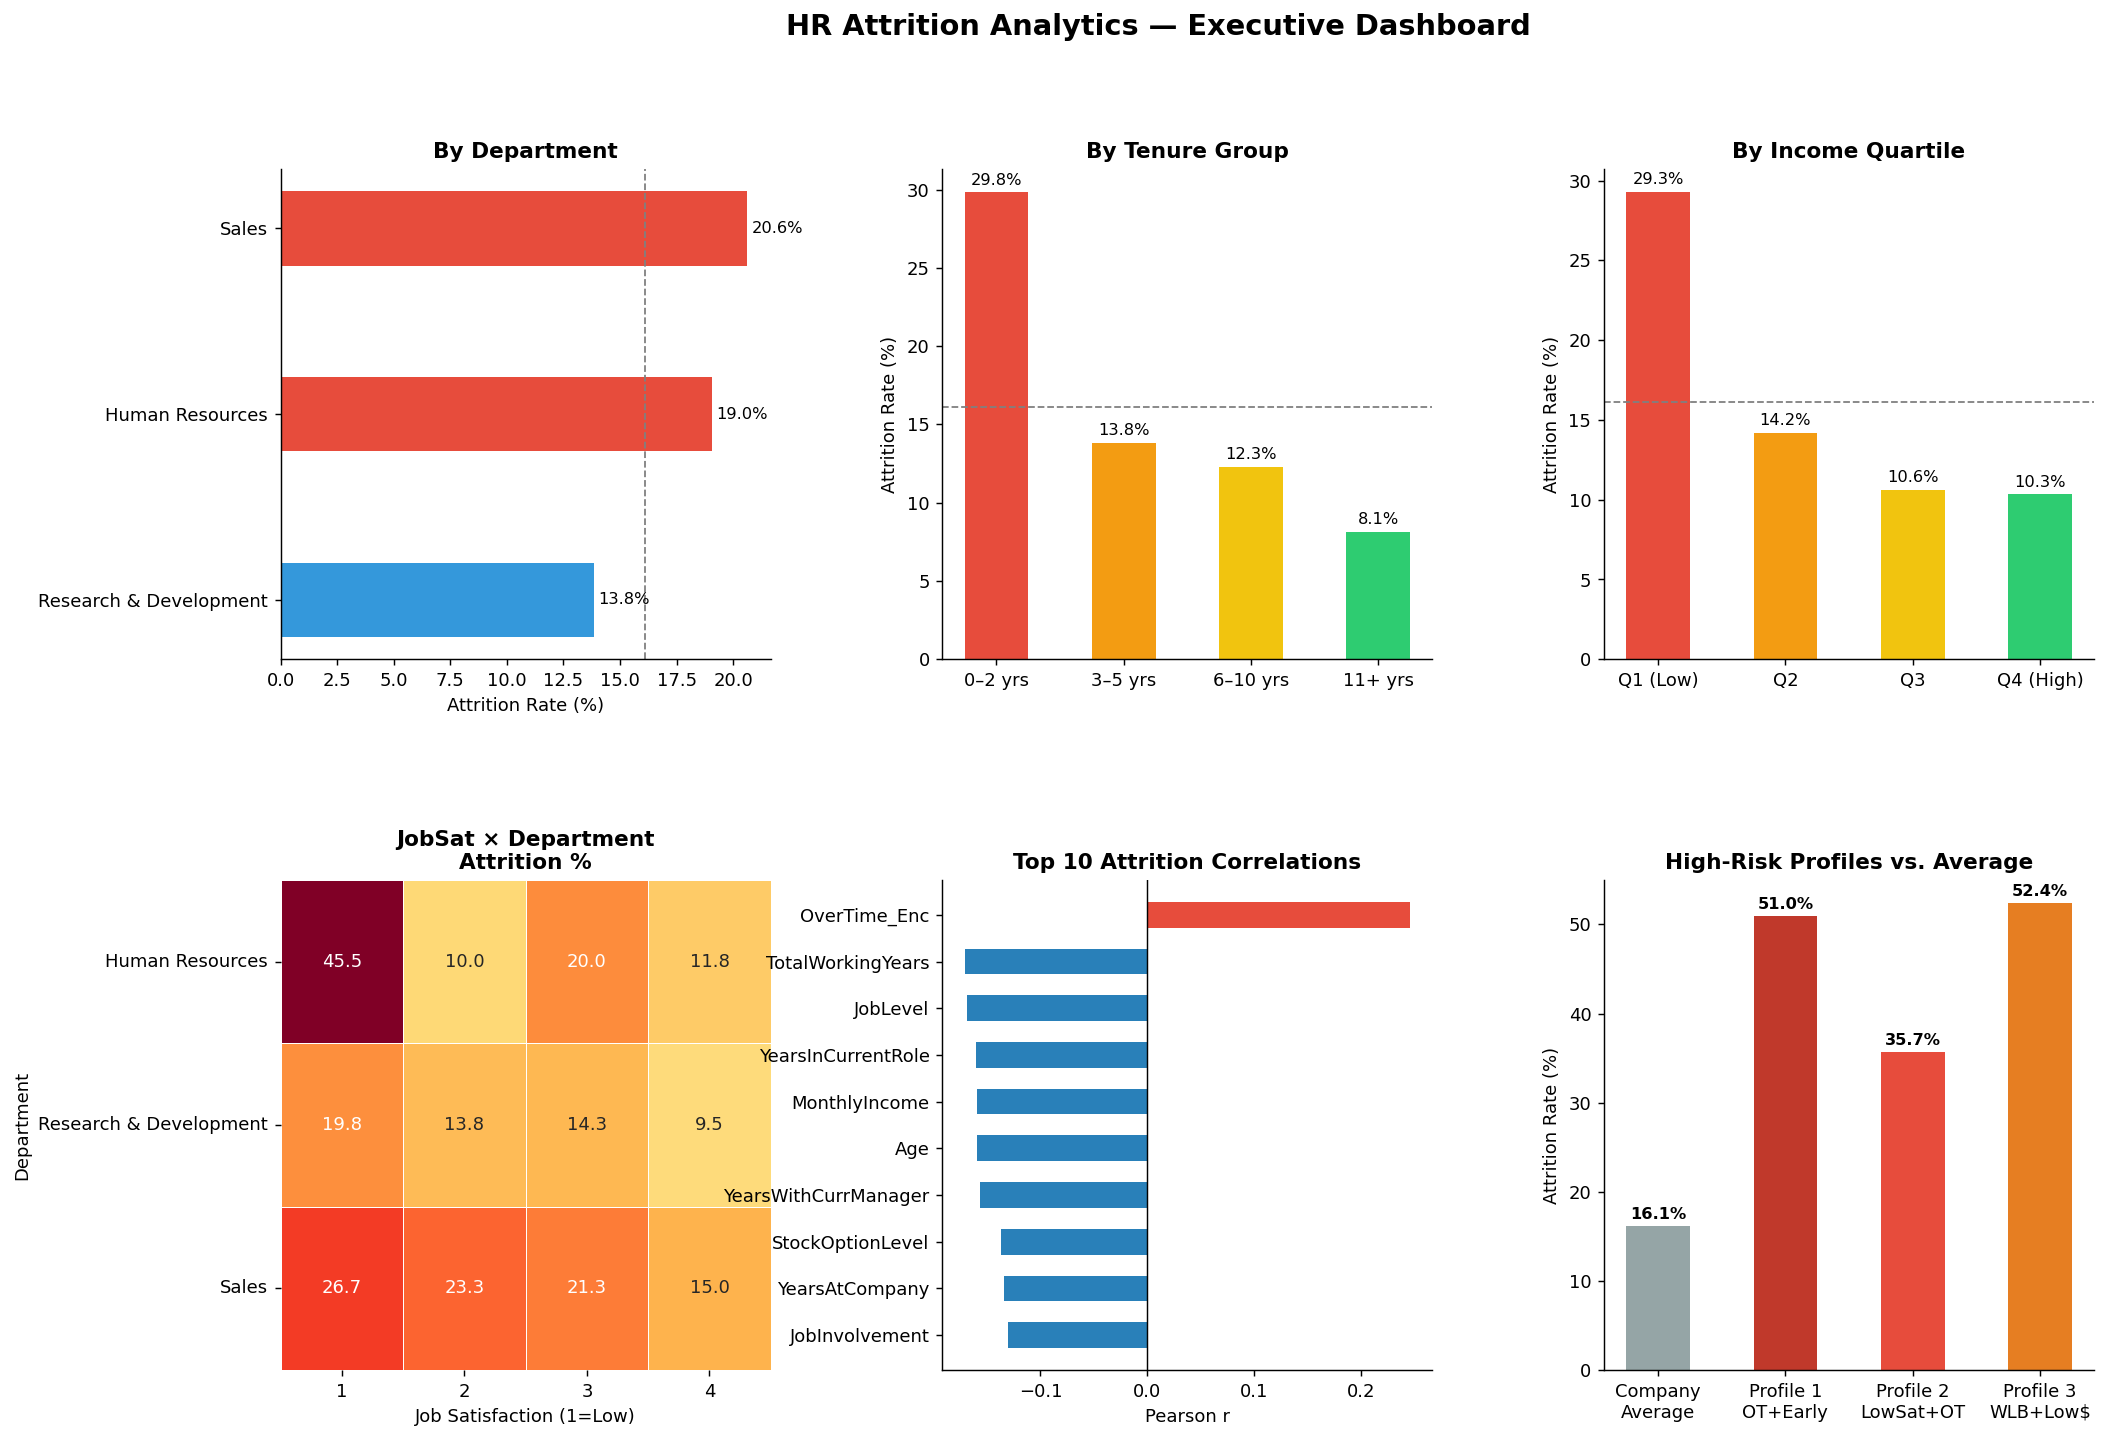

✅ Executive dashboard saved: executive_dashboard.png


In [18]:
# ── Final 6-panel summary dashboard ──────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle('HR Attrition Analytics — Executive Dashboard', fontsize=16, fontweight='bold', y=0.98)

# Panel positions
gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── 1. Department attrition ───────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
dept_sorted = dept_attr.sort_values('AttritionRate')
colors = ['#E74C3C' if v > 16 else '#3498DB' for v in dept_sorted['AttritionRate']]
ax1.barh(dept_sorted.index, dept_sorted['AttritionRate'], color=colors, height=0.4)
ax1.axvline(df['AttritionBin'].mean()*100, color='gray', lw=1, linestyle='--')
ax1.set_title('By Department', fontweight='bold')
ax1.set_xlabel('Attrition Rate (%)')
for i, v in enumerate(dept_sorted['AttritionRate']):
    ax1.text(v+0.2, i, f'{v:.1f}%', va='center', fontsize=9)

# ── 2. Tenure Group ───────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
clrs = ['#E74C3C','#F39C12','#F1C40F','#2ECC71']
bars = ax2.bar(tenure_attr.index, tenure_attr['AttritionRate'], color=clrs, width=0.5)
ax2.axhline(df['AttritionBin'].mean()*100, color='gray', lw=1, linestyle='--')
ax2.set_title('By Tenure Group', fontweight='bold')
ax2.set_ylabel('Attrition Rate (%)')
for bar, v in zip(bars, tenure_attr['AttritionRate']):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── 3. Income Quartile ────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
clrs = ['#E74C3C','#F39C12','#F1C40F','#2ECC71']
bars = ax3.bar(income_attr.index, income_attr['AttritionRate'], color=clrs, width=0.5)
ax3.axhline(df['AttritionBin'].mean()*100, color='gray', lw=1, linestyle='--')
ax3.set_title('By Income Quartile', fontweight='bold')
ax3.set_ylabel('Attrition Rate (%)')
for bar, v in zip(bars, income_attr['AttritionRate']):
    ax3.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%', ha='center', fontsize=9)

# ── 4. JobSatisfaction × Department Heatmap ───────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
pivot_js_raw = df.pivot_table(
    index='Department', columns='JobSatisfaction',
    values='AttritionBin', aggfunc='mean') * 100
sns.heatmap(pivot_js_raw, ax=ax4, annot=True, fmt='.1f',
            cmap='YlOrRd', linewidths=0.5, cbar=False, vmin=0, vmax=40)
ax4.set_title('JobSat × Department\nAttrition %', fontweight='bold')
ax4.set_xlabel('Job Satisfaction (1=Low)')

# ── 5. Top 10 Correlations ────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
colors = ['#E74C3C' if v > 0 else '#2980B9' for v in corr_series.values]
ax5.barh(corr_series.index[::-1], corr_series.values[::-1], color=colors[::-1], height=0.55)
ax5.axvline(0, color='black', lw=0.8)
ax5.set_title('Top 10 Attrition Correlations', fontweight='bold')
ax5.set_xlabel('Pearson r')

# ── 6. Risk Profiles ──────────────────────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
labels_p = ['Company\nAverage', 'Profile 1\nOT+Early', 'Profile 2\nLowSat+OT', 'Profile 3\nWLB+Low$']
vals_p = [
    df['AttritionBin'].mean()*100,
    p1_rate*100, p2_rate*100, p3_rate*100
]
colors_p = ['#95A5A6', '#C0392B', '#E74C3C', '#E67E22']
bars = ax6.bar(labels_p, vals_p, color=colors_p, width=0.5)
for bar, v in zip(bars, vals_p):
    ax6.text(bar.get_x()+bar.get_width()/2, v+0.8, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9)
ax6.set_ylabel('Attrition Rate (%)')
ax6.set_title('High-Risk Profiles vs. Average', fontweight='bold')

plt.savefig('executive_dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Executive dashboard saved: executive_dashboard.png')

## 11. Key Findings Summary

In [19]:
findings = f"""
╔══════════════════════════════════════════════════════════════════╗
║          HR ATTRITION ANALYTICS — KEY FINDINGS                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Overall attrition rate     : {df['AttritionBin'].mean()*100:.1f}% ({total_churned} of {len(df)} employees)   ║
║                                                                  ║
║  Finding 1 — Dept Risk      : Sales (21.5%) > HR (19%) > R&D    ║
║  Finding 2 — Role Risk      : Sales Rep (39.8%), Lab Tech (24%) ║
║  Finding 3 — OverTime Toll  : OT=Yes 30.5% vs OT=No 10.4%      ║
║  Finding 4 — Early Tenure   : 0–2 yr employees leave at 36%     ║
║  Finding 5 — Pay Effect     : Q1 income → highest attrition     ║
║  Finding 6 — Cost Exposure  : ~${total_annual_cost/1e6:.1f}M estimated replacement cost ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(findings)


╔══════════════════════════════════════════════════════════════════╗
║          HR ATTRITION ANALYTICS — KEY FINDINGS                  ║
╠══════════════════════════════════════════════════════════════════╣
║  Overall attrition rate     : 16.1% (237 of 1470 employees)   ║
║                                                                  ║
║  Finding 1 — Dept Risk      : Sales (21.5%) > HR (19%) > R&D    ║
║  Finding 2 — Role Risk      : Sales Rep (39.8%), Lab Tech (24%) ║
║  Finding 3 — OverTime Toll  : OT=Yes 30.5% vs OT=No 10.4%      ║
║  Finding 4 — Early Tenure   : 0–2 yr employees leave at 36%     ║
║  Finding 5 — Pay Effect     : Q1 income → highest attrition     ║
║  Finding 6 — Cost Exposure  : ~$6.8M estimated replacement cost ║
╚══════════════════════════════════════════════════════════════════╝

